## Land cover detection and moving windows
- Computing NDVI and NDWI with Landsat images 
- computing moving windows and study the correlations with LST depending on the size of the window.


### libraries and general paths

In [1]:
import os
import rasterio
from rasterio.mask import mask
from rasterio.warp import transform_geom
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap




In [3]:
# Rasters
lst_path = '../../../datos-notebooks/0.LST/LC09_L2SP_192029_20240809_20240810_02_T1_ST_B10.tif' 
green_path = '../../../datos-notebooks/2.global-data-bologna/2.1.land-cover/landsat-bands/LC09_L2SP_192029_20240809_20240810_02_T1_SR_B3.TIF'
red_path = '../../../datos-notebooks/2.global-data-bologna/2.1.land-cover/landsat-bands/LC09_L2SP_192029_20240809_20240810_02_T1_SR_B4.TIF'
nir_path = '../../../datos-notebooks/2.global-data-bologna/2.1.land-cover/landsat-bands/LC09_L2SP_192029_20240809_20240810_02_T1_SR_B5.TIF'

lst_cropped_path = '../../../datos-notebooks/0.LST/LST_cropped_celsius.tif' # values out of bound are 0
lst_clipped_path = '../../../datos-notebooks/0.LST/LST_clipped_celsius.tif' #values out of bound are nan


# Boundary
bound = "../../../datos-notebooks/bologne_boundary.geojson"
gdf = gpd.read_file(bound)

# Folders
output_folder_ndvi = '../../../datos-notebooks/2.global-data-bologna/2.1.land-cover/ndvi'   
os.makedirs(output_folder_ndvi, exist_ok=True)
output_folder_ndwi = '../../../datos-notebooks/2.global-data-bologna/2.1.land-cover/ndwi'   
os.makedirs(output_folder_ndwi, exist_ok=True)
output_folder_mw = "../../../datos-notebooks/2.global-data-bologna/2.1.land-cover/moving-windows"
os.makedirs(output_folder_mw, exist_ok=True)  

# Indexes
ndvi_path = f"{output_folder_ndvi}/ndvi.tif"
ndwi_path = f"{output_folder_ndwi}/ndwi.tif"

# Classified indexes
ndvi_1_path = f"{output_folder_ndvi}/ndvi_1.tif"
ndvi_0p5_path = f"{output_folder_ndvi}/ndvi_0p5.tif"
ndwi_1_path = f"{output_folder_ndwi}/ndwi_1.tif"

###  Cropping images and computing NDVI, NDWI

In [ ]:
# Get LST extent + metadata for outputs
with rasterio.open(lst_cropped_path) as lst_src:
    lst_bounds = lst_src.bounds
    lst_geom = [{
        "type": "Polygon",
        "coordinates": [[
            (lst_bounds.left,  lst_bounds.bottom),
            (lst_bounds.left,  lst_bounds.top),
            (lst_bounds.right, lst_bounds.top),
            (lst_bounds.right, lst_bounds.bottom),
            (lst_bounds.left,  lst_bounds.bottom)
        ]]
    }]
    out_meta = lst_src.meta.copy()
    out_meta.update(dtype="float32", count=1, nodata=np.nan)

# get geometry for cropping
lst_geom = [{
    "type": "Polygon",
    "coordinates": [[
        (lst_bounds.left,  lst_bounds.bottom),
        (lst_bounds.left,  lst_bounds.top),
        (lst_bounds.right, lst_bounds.top),
        (lst_bounds.right, lst_bounds.bottom),
        (lst_bounds.left,  lst_bounds.bottom)
    ]]
}]

In [ ]:
# Crop 
def crop_band(path, geom):
    """Crop band to LST extent"""
    with rasterio.open(path) as src:
        data, _ = mask(src, geom, crop=True)
        return data[0].astype("float32")

green = crop_band(green_path, lst_geom)
red   = crop_band(red_path,   lst_geom)
nir   = crop_band(nir_path,   lst_geom)

np.seterr(divide="ignore", invalid="ignore")

# Indices
ndvi = (nir - red) / (nir + red)
ndwi = (green - nir) / (green + nir) 

# Save outputs
with rasterio.open(ndvi_path, "w", **out_meta) as dst:
    dst.write(ndvi.astype("float32"), 1)

with rasterio.open(ndwi_path, "w", **out_meta) as dst:
    dst.write(ndwi.astype("float32"), 1)


In [ ]:
with rasterio.open(ndvi_path) as src:
    ndvi = src.read(1)

with rasterio.open(ndwi_path) as src:
    ndwi = src.read(1)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# NDVI
im1 = axs[0].imshow(ndvi, cmap="Greens")
axs[0].set_title("NDVI")
axs[0].axis("off")
plt.colorbar(im1, ax=axs[0], fraction=0.046)

# NDWI
im2 = axs[1].imshow(ndwi, cmap="Blues", vmin=0, vmax=0.1)
axs[1].set_title("NDWI")
axs[1].axis("off")
plt.colorbar(im2, ax=axs[1], fraction=0.046)

plt.tight_layout()
plt.show()


#### classifying values

In [ ]:
with rasterio.open(ndvi_path) as src:
    ndvi = src.read(1)

with rasterio.open(ndwi_path) as src:
    ndwi = src.read(1)
    
ndvi_1 = np.where(ndvi > 0.3, 1, 0).astype('float32')
ndvi_0p5 = np.where((ndvi > 0.2) & (ndvi <= 0.3),1,0).astype('float32')
ndwi_1 = np.where(ndwi > 0.4, 1, 0).astype('float32')

# Save outputs
with rasterio.open(lst_cropped_path) as lst_src:
    out_meta = lst_src.meta.copy()
    out_meta.update(dtype="float32", count=1, nodata=np.nan)

with rasterio.open(ndvi_1_path, "w", **out_meta) as dst:
    dst.write(ndvi_1.astype("float32"), 1)
    
with rasterio.open(ndvi_0p5_path, "w", **out_meta) as dst:
    dst.write(ndvi_0p5.astype("float32"), 1)

with rasterio.open(ndwi_1_path, "w", **out_meta) as dst:
    dst.write(ndwi.astype("float32"), 1)

In [ ]:
with rasterio.open(ndvi_1_path) as src:
    ndvi_1 = src.read(1)

with rasterio.open(ndvi_0p5_path) as src:
    ndvi_0p5 = src.read(1)
    
with rasterio.open(ndwi_1_path) as src:
    ndwi_1 = src.read(1)

fig, axs = plt.subplots(1, 3, figsize=(12, 5))

# NDVI_1
im1 = axs[0].imshow(ndvi_1, cmap="Greens")
axs[0].set_title("NDVI>0.3")
axs[0].axis("off")

# NDVI_0.5
im1 = axs[1].imshow(ndvi_0p5, cmap="Greens")
axs[1].set_title("NDVI>0.2&<0.3")
axs[1].axis("off")

# NDWI
im2 = axs[2].imshow(ndwi, cmap="Blues", vmin=0, vmax=0.1)
axs[2].set_title("NDWI>0.4")
axs[2].axis("off")

plt.tight_layout()
plt.show()


### moving windows 

In [ ]:
def distance_weighted_kernel(size):
    """Create a distance-weighted Gaussian kernel."""
    assert size % 2 == 1, "Window size must be odd"
    center = size // 2
    y, x = np.ogrid[:size, :size]
    distance = np.sqrt((x - center)**2 + (y - center)**2)
    sigma = size / 4  # controls smoothing strength
    weights = np.exp(-(distance**2) / (2 * sigma**2))
    weights /= weights.sum()  # normalize to sum=1
    return weights


def moving_window_weighted(array, kernel):
    """Apply distance-weighted convolution."""
    return convolve(array, kernel, mode='nearest')


#### NDVI

In [ ]:
ndvi_paths = {
    "class_1": ndvi_1_path,
    "class_0p5": ndvi_0p5_path,
}

output_folder_mw_ndvi = os.path.join(output_folder_mw, "ndvi/")
os.makedirs(output_folder_mw_ndvi, exist_ok=True)
    

In [ ]:
# Loop over classes
for class_name, path in ndvi_paths.items():
    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)
        profile = src.profile

        # Loop over window sizes (ONLY odd sizes)
        for window_size in range(1, 101, 2):  
            kernel = distance_weighted_kernel(window_size)
            smoothed = moving_window_weighted(data, kernel)

            # Save raster
            out_profile = profile.copy()
            out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')
            out_path = os.path.join(
                output_folder_mw_ndvi, 
                f"{class_name}_window{window_size}.tif"
            )

            with rasterio.open(out_path, "w", **out_profile) as dst:
                dst.write(smoothed.astype(np.float32), 1)


In [ ]:
# plot for one class

class_n = "class_1"

fig, axes = plt.subplots(2, 5, figsize=(8, 8))  
axes = axes.flatten()

for window_size in range(1, 21,2):
    raster_path = os.path.join(output_folder_mw_ndvi, f"{class_n}_window{window_size}.tif")
    with rasterio.open(raster_path) as src:
        data, out_transform = mask(src, gdf.geometry, crop=True) #crop the plot
        data = data[0]

    ax = axes[(window_size - 1)//2]
    im = ax.imshow(data, cmap="YlGn")
    ax.set_title(f"Window {window_size}x{window_size}")
    ax.axis("off")

fig.suptitle(f"{class_n} - Moving window", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
classes = ["class_1", "class_0p5"]

window_sizes = list(range(1, 21, 2))  # odd windows

for class_name in classes:
    fig, axes = plt.subplots(2, 5, figsize=(20, 8)) 
    axes = axes.flatten()

    for ax, w in zip(axes, window_sizes):
        raster_path = os.path.join(
            output_folder_mw_ndvi, 
            f"{class_name}_window{w}.tif"
        )

        with rasterio.open(raster_path) as src:
            data, _ = mask(src, gdf.geometry, crop=True) #crop the plot
            data = data[0]

        im = ax.imshow(data, cmap="YlGn")
        ax.set_title(f"Window {w}x{w}")
        ax.axis("off")

    fig.suptitle(f"NDVI - {class_name} - Distance-weighted moving window", fontsize=16)
    plt.tight_layout()
    plt.show()



#### NDWI

In [4]:
output_folder_mw_ndwi = os.path.join(output_folder_mw, "ndwi/")
os.makedirs(output_folder_mw_ndwi, exist_ok=True)

In [ ]:
output_folder_ndwi = '../../../datos-notebooks/2.global-data-bologna/2.1.land-cover/ndwi'   
os.makedirs(output_folder_ndwi, exist_ok=True)

output_folder_mw = "../../../datos-notebooks/2.global-data-bologna/2.1.land-cover/moving-windows"
os.makedirs(output_folder_mw, exist_ok=True)  

output_folder_mw_ndwi = os.path.join(output_folder_mw, "ndwi/")
os.makedirs(output_folder_mw_ndwi, exist_ok=True)

# Indexes
ndvi_path = f"{output_folder_ndvi}/ndvi.tif"
ndwi_path = f"{output_folder_ndwi}/ndwi.tif"

# Classified indexes
ndvi_1_path = f"{output_folder_ndvi}/ndvi_1.tif"
ndvi_0p5_path = f"{output_folder_ndvi}/ndvi_0p5.tif"
ndwi_1_path = f"{output_folder_ndwi}/ndwi_1.tif"

In [5]:
with rasterio.open(ndwi_1_path) as src:
    data = src.read(1).astype(np.float32)
    profile = src.profile

    # Loop over window sizes (ONLY odd sizes)
    for window_size in range(1, 101, 2):  
        kernel = distance_weighted_kernel(window_size)
        smoothed = moving_window_weighted(data, kernel)

        # Save raster
        out_profile = profile.copy()
        out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')
        out_path = os.path.join(
            output_folder_mw_ndwi, 
            f"class_1_window{window_size}.tif"
        )

        with rasterio.open(out_path, "w", **out_profile) as dst:
            dst.write(smoothed.astype(np.float32), 1)



NameError: name 'distance_weighted_kernel' is not defined

../../../datos-notebooks/2.global-data-bologna/2.1.land-cover/moving-windows\ndwi/class_1_window1.tif
../../../datos-notebooks/2.global-data-bologna/2.1.land-cover/moving-windows\ndwi/class_1_window3.tif
../../../datos-notebooks/2.global-data-bologna/2.1.land-cover/moving-windows\ndwi/class_1_window5.tif
../../../datos-notebooks/2.global-data-bologna/2.1.land-cover/moving-windows\ndwi/class_1_window7.tif
../../../datos-notebooks/2.global-data-bologna/2.1.land-cover/moving-windows\ndwi/class_1_window9.tif
../../../datos-notebooks/2.global-data-bologna/2.1.land-cover/moving-windows\ndwi/class_1_window11.tif
../../../datos-notebooks/2.global-data-bologna/2.1.land-cover/moving-windows\ndwi/class_1_window13.tif
../../../datos-notebooks/2.global-data-bologna/2.1.land-cover/moving-windows\ndwi/class_1_window15.tif
../../../datos-notebooks/2.global-data-bologna/2.1.land-cover/moving-windows\ndwi/class_1_window17.tif
../../../datos-notebooks/2.global-data-bologna/2.1.land-cover/moving-windows\n

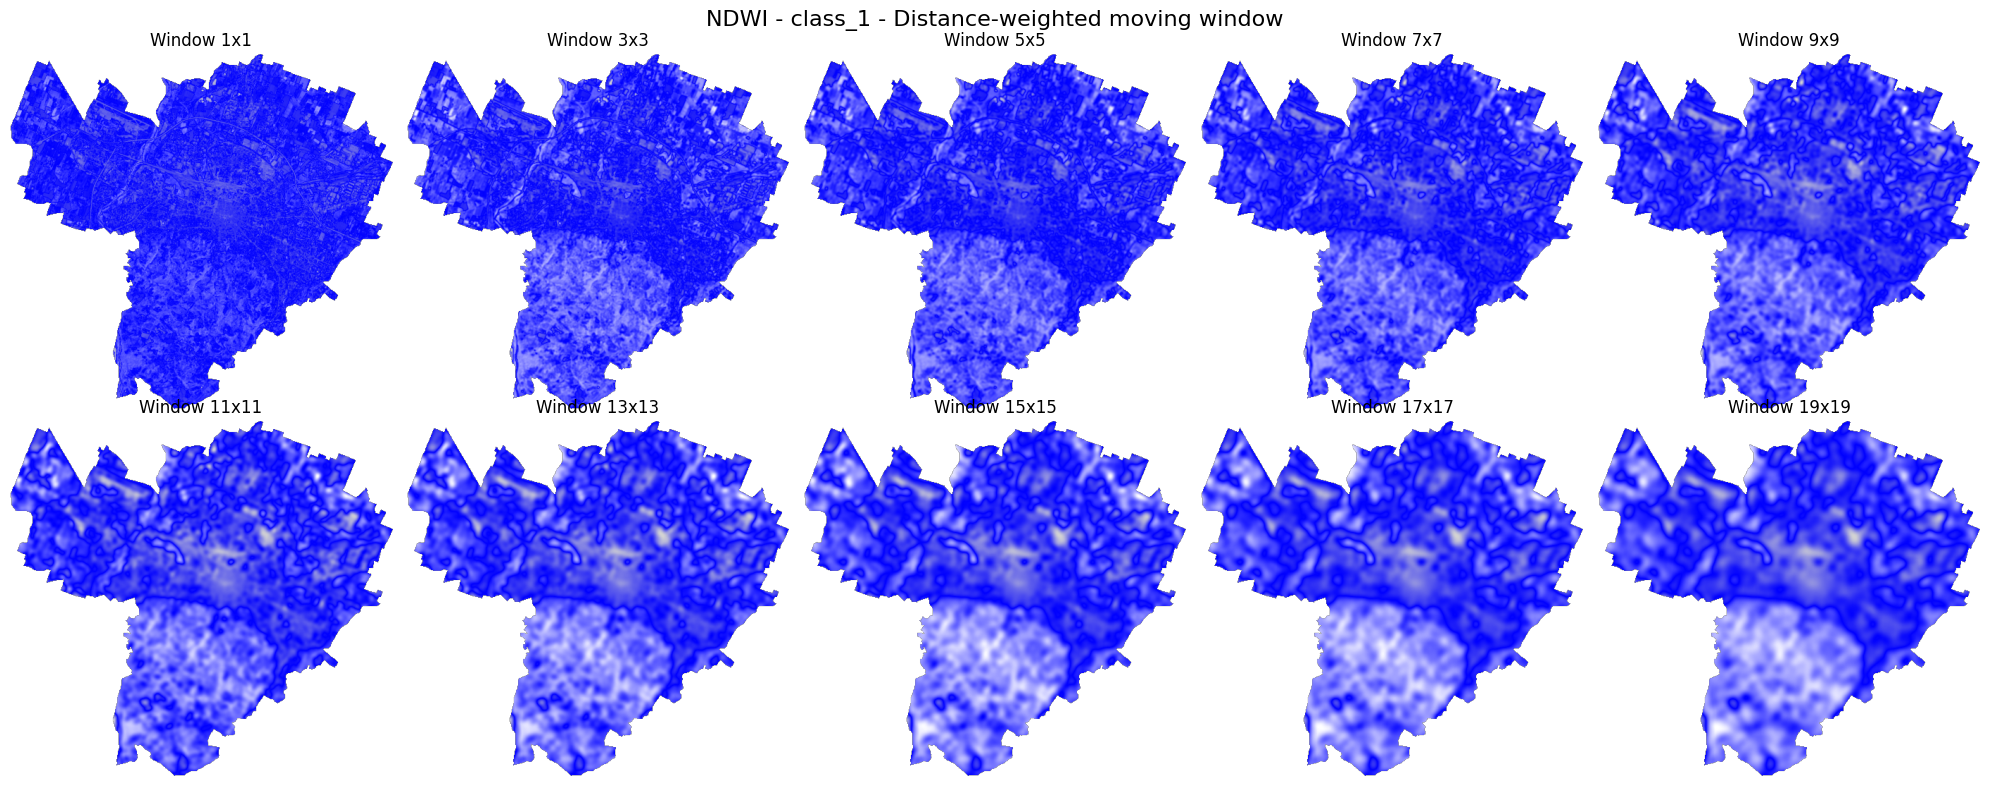

In [ ]:
# Define custom colormap
colors = ["white", "blue", "lightgrey"]
custom_cmap = LinearSegmentedColormap.from_list("white_blue_purple", colors)

window_sizes = list(range(1, 21, 2))  # odd windows only 

fig, axes = plt.subplots(2, 5, figsize=(20, 8)) 
axes = axes.flatten()

for ax, w in zip(axes, window_sizes):
    raster_path = os.path.join(
        output_folder_mw_ndwi, 
        f"class_1_window{w}.tif"
    )
    with rasterio.open(raster_path) as src:
        data, _ = mask(src, gdf.geometry, crop=True)
        data = data[0]

    im = ax.imshow(data, cmap=custom_cmap)
    ax.set_title(f"Window {w}x{w}")
    ax.axis("off")

fig.suptitle(f"NDWI - class_1 - Distance-weighted moving window", fontsize=16)
plt.tight_layout()
plt.show()


### Correlations with LST

In [ ]:
# Paths
ndvi_folder = "../../datos-notebooks/1.land-cover/moving-windows/ndvi/"
ndwi_folder = "../../datos-notebooks/1.land-cover/moving-windows/ndwi/"

# general parameters
window_sizes = range(1, 101, 2)

# --- Load LST ---
with rasterio.open(lst_clipped_path) as lst:
    lst_crs = lst.crs
    lst_clip = lst.read(1)          
    lst_transform = lst.transform   

#### NDVI-LST

##### CLASS 1 (dense vegetation)

In [ ]:
correlations = []

for w in window_sizes:
    ndvi_path = os.path.join(ndvi_folder, f"class_1_window{w}.tif")
    with rasterio.open(ndvi_path) as src_ndvi:
        ndvi_crop, ndvi_transform = mask(src_ndvi, gdf.geometry, crop=True)
        ndvi_crop = ndvi_crop[0].astype(float)

    # Pixel-by-pixel correlation using only valid LST pixels ---
    valid_mask = ~np.isnan(lst_clip)  # Ignore pixels where LST is NaN
    ndvi_vals = ndvi_crop[valid_mask]
    lst_vals = lst_clip[valid_mask]

    corr = np.corrcoef(ndvi_vals, lst_vals)[0,1]
    correlations.append(corr)

# Plot
plt.figure(figsize=(8,5))
plt.plot(window_sizes, correlations, marker='o')
plt.xlabel("Window size (pixels)")
plt.ylabel("Correlation NDVI class 1 – LST")
plt.title("Correlation vs window size")
plt.grid(True)
plt.show()



##### Class 0 (no vegetation)

In [ ]:

correlations = []

for w in window_sizes:
    ndvi_path = os.path.join(ndvi_folder, f"class_0_window{w}.tif")
    with rasterio.open(ndvi_path) as src_ndvi:
        gdf_ndvi = gdf.to_crs(src_ndvi.crs)
        ndvi_crop, ndvi_transform = mask(src_ndvi, gdf_ndvi.geometry, crop=True)
        ndvi_crop = ndvi_crop[0].astype(float)

    # --- Pixel-by-pixel correlation using only valid LST pixels ---
    valid_mask = ~np.isnan(lst_clip)  # Ignore pixels where LST is NaN
    ndvi_vals = ndvi_crop[valid_mask]
    lst_vals = lst_clip[valid_mask]

    corr = np.corrcoef(ndvi_vals, lst_vals)[0,1]
    correlations.append(corr)

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(window_sizes, correlations, marker='o')
plt.xlabel("Window size (pixels)")
plt.ylabel("Correlation NDVI class 0 – LST")
plt.title("Correlation vs window size")
plt.grid(True)
plt.show()



##### Class 0.5 (mid vegetation)

In [ ]:
correlations = []

for w in window_sizes:
    ndvi_path = os.path.join(ndvi_folder, f"class_0p5_window{w}.tif")
    with rasterio.open(ndvi_path) as src_ndvi:
        ndvi_crop, ndvi_transform = mask(src_ndvi, gdf.geometry, crop=True)
        ndvi_crop = ndvi_crop[0].astype(float)

    # Pixel-by-pixel correlation using only valid LST pixels ---
    valid_mask = ~np.isnan(lst_clip)  # Ignore pixels where LST is NaN
    ndvi_vals = ndvi_crop[valid_mask]
    lst_vals = lst_clip[valid_mask]

    corr = np.corrcoef(ndvi_vals, lst_vals)[0,1]
    correlations.append(corr)

# Plot
plt.figure(figsize=(8,5))
plt.plot(window_sizes, correlations, marker='o')
plt.xlabel("Window size (pixels)")
plt.ylabel("Correlation NDVI class 0.5 – LST")
plt.title("Correlation vs window size")
plt.grid(True)
plt.show()


#### NDWI-LST

In [ ]:
correlations = []

for w in window_sizes:
    ndwi_path = os.path.join(ndwi_folder, f"class_1_window{w}.tif")
    with rasterio.open(ndwi_path) as src_ndwi:
        gdf_ndwi = gdf.to_crs(src_ndwi.crs)
        ndwi_crop, ndwi_transform = mask(src_ndwi, gdf_ndwi.geometry, crop=True)
        ndwi_crop = ndwi_crop[0].astype(float)

    # --- Pixel-by-pixel correlation using only valid LST pixels ---
    valid_mask = ~np.isnan(lst_clip)  
    ndwi_vals = ndwi_crop[valid_mask]
    lst_vals = lst_clip[valid_mask]

    corr = np.corrcoef(ndwi_vals, lst_vals)[0,1]
    correlations.append(corr)

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(window_sizes, correlations, marker='o')
plt.xlabel("Window size (pixels)")
plt.ylabel("Correlation NDWI class 1 – LST")
plt.title("Correlation vs window size")
plt.grid(True)
plt.show()